# EDA inicial - Requerimientos (No supervisado)

Objetivo: explorar calidad y estructura de datos para preparar un modelo no supervisado usando únicamente short_description y description.
Variables de fuga como assignment_group y assigned_to no se usarán para modelado.

In [51]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import unicodedata
from pathlib import Path

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

In [52]:
# 1) Carga robusta del CSV objetivo (funciona desde raíz o desde Data)
from pathlib import Path
import pandas as pd

nombre_csv = "requerimientos_2026-05-28_17-09-55.csv"
cwd = Path.cwd()

candidatas = [
    cwd / nombre_csv,           # si el notebook corre desde Data
    cwd / "Data" / nombre_csv,  # si corre desde la raíz del proyecto
]

ruta_csv = next((p for p in candidatas if p.exists()), None)

if ruta_csv is None:
    buscados = "\n".join(str(p.resolve()) for p in candidatas)
    raise FileNotFoundError(f"No existe el archivo en ninguna ruta candidata:\n{buscados}")

print("Archivo seleccionado:", ruta_csv.resolve())

df = pd.read_csv(
    ruta_csv,
    sep=";",
    encoding="latin-1",
    dtype=str,
    engine="python",
    on_bad_lines="skip"
)

print("Dimensiones:", df.shape)
display(df.head(3))
print("\nColumnas:")
print(df.columns.tolist())

Archivo seleccionado: C:\ASIGNADOR\Asignador\Data\requerimientos_2026-05-28_17-09-55.csv
Dimensiones: (11216, 13)


,number,state,ref_sc_req_item.requested_for,requested_for.vip,requested_for.email,requested_for.title,requested_for.company,assigned_to,assignment_group,short_description,cat_item.sc_catalogs,description,u_variables_texto
0,RITM0716416,Cerrado,ANGELA MERCEDES OBANDO BERNAL,falso,amobando@pichincha.com,EJECUTIVO BACK Y SERVICIOS,Banco Pichincha C.A.,KONERI DAMODARAM,TEC_TCS_BANCS,Requerimientos de información relacionados a B...,TI,Estimados su gentil ayuda con el cambio de es...,NaN
1,RITM0620071,Cerrado,JHOSUE DAVID BRITO ASTUDILLO,falso,jbritoas@pichincha.com,SOPORTE ADMINISTRATIVO,Banco Pichincha C.A.,MARCELA YADIRA ZUNIGA UBILLUZ,TEC_TCS_BANCS,Requerimientos de información relacionados a B...,TI,¿Cómo se genera la información del archivo de ...,NaN
2,RITM0754745,Cerrado,XIOMARA ELIZABETH CEVALLOS TENORIO,falso,xecevall@pichincha.com,EJECUTIVO COMERCIAL RELACIONAL,Banco Pichincha C.A.,LEONELA JACKELINE DELGADO MENDIETA,TEC_TCS_BANCS,Requerimientos de información relacionados a B...,TI,¿Buenos días por favor su ayuda con revisión a...,NaN



Columnas:
['number', 'state', 'ref_sc_req_item.requested_for', 'requested_for.vip', 'requested_for.email', 'requested_for.title', 'requested_for.company', 'assigned_to', 'assignment_group', 'short_description', 'cat_item.sc_catalogs', 'description', 'u_variables_texto']


In [53]:
# 2) Definir columnas para modelado no supervisado
cols_texto = ["short_description", "description"]
faltantes = [c for c in cols_texto if c not in df.columns]
if faltantes:
    raise ValueError(f"Faltan columnas críticas: {faltantes}")

# Solo dejamos columnas útiles para esta fase
cols_base = [c for c in ["number", "state"] if c in df.columns] + cols_texto
df_eda = df[cols_base].copy()

print("Columnas en df_eda:", df_eda.columns.tolist())
print("Registros:", len(df_eda))
display(df_eda.head(3))

Columnas en df_eda: ['number', 'state', 'short_description', 'description']
Registros: 11216


,number,state,short_description,description
0,RITM0716416,Cerrado,Requerimientos de información relacionados a B...,Estimados su gentil ayuda con el cambio de es...
1,RITM0620071,Cerrado,Requerimientos de información relacionados a B...,¿Cómo se genera la información del archivo de ...
2,RITM0754745,Cerrado,Requerimientos de información relacionados a B...,¿Buenos días por favor su ayuda con revisión a...


In [54]:
# 3) Calidad de datos de texto: nulos, vacíos, cardinalidad

def es_vacio(x):
    if pd.isna(x):
        return True
    s = str(x).strip().lower()
    return s in {"", "nan", "none", "null"}

resumen_calidad = []
for c in cols_texto:
    vacios = df_eda[c].apply(es_vacio).sum()
    resumen_calidad.append({
        "columna": c,
        "n_registros": len(df_eda),
        "n_vacios": int(vacios),
        "pct_vacios": round(vacios / len(df_eda) * 100, 2),
        "n_unicos_no_nulos": int(df_eda[c].nunique(dropna=True))
    })

resumen_calidad = pd.DataFrame(resumen_calidad)
display(resumen_calidad)

,columna,n_registros,n_vacios,pct_vacios,n_unicos_no_nulos
0,short_description,11216,0,0.0,32
1,description,11216,1323,11.8,9264


In [55]:
# 4) Construir texto unificado SOLO con short_description + description
df_eda["texto_unificado_raw"] = (
    df_eda["short_description"].fillna("").astype(str).str.strip() + " " +
    df_eda["description"].fillna("").astype(str).str.strip()
).str.replace(r"\s+", " ", regex=True).str.strip()

df_eda["texto_vacio"] = df_eda["texto_unificado_raw"].eq("")

print("Registros sin texto útil:", int(df_eda["texto_vacio"].sum()))
print("Porcentaje sin texto útil:", round(df_eda["texto_vacio"].mean() * 100, 2), "%")
display(df_eda[["texto_unificado_raw", "texto_vacio"]].head(5))

Registros sin texto útil: 0
Porcentaje sin texto útil: 0.0 %


,texto_unificado_raw,texto_vacio
0,Requerimientos de información relacionados a B...,False
1,Requerimientos de información relacionados a B...,False
2,Requerimientos de información relacionados a B...,False
3,Requerimientos de información relacionados a B...,False
4,Requerimientos de información relacionados a B...,False


In [56]:
# 5) Duplicados exactos (muy importante para clustering)
dup_pair = df_eda[cols_texto].fillna("").duplicated(keep=False)
dup_texto = df_eda["texto_unificado_raw"].duplicated(keep=False)

print("Duplicados por (short_description, description):", int(dup_pair.sum()))
print("Duplicados por texto_unificado_raw:", int(dup_texto.sum()))

# Muestra de ejemplos duplicados
ej_dup = df_eda.loc[dup_texto, ["number", "short_description", "description", "texto_unificado_raw"]].head(10)
display(ej_dup)

Duplicados por (short_description, description): 2244
Duplicados por texto_unificado_raw: 2289


,number,short_description,description,texto_unificado_raw
6,RITM0658358,Requerimientos de información relacionados a B...,Versionar el proceso dev_check.sh y posterior ...,Requerimientos de información relacionados a B...
7,RITM0594481,Requerimientos de información relacionados a B...,Versionar el proceso dev_check.sh y posterior ...,Requerimientos de información relacionados a B...
8,RITM0625900,Requerimientos de información relacionados a B...,Versionar el proceso dev_check.sh y posterior ...,Requerimientos de información relacionados a B...
36,RITM0725104,Requerimientos de información relacionados a B...,Ver movimientos de BANCS para el incidente INC...,Requerimientos de información relacionados a B...
37,RITM0718982,Requerimientos de información relacionados a B...,Ver movimientos de BANCS para el incidente INC...,Requerimientos de información relacionados a B...
63,RITM0698508,Requerimientos de información relacionados a B...,Ver movimientos de BANCS para el incidente INC...,Requerimientos de información relacionados a B...
64,RITM0698553,Requerimientos de información relacionados a B...,Ver movimientos de BANCS para el incidente INC...,Requerimientos de información relacionados a B...
71,RITM0698520,Requerimientos de información relacionados a B...,Ver movimientos de BANCS para el incidente INC...,Requerimientos de información relacionados a B...
72,RITM0698567,Requerimientos de información relacionados a B...,Ver movimientos de BANCS para el incidente INC...,Requerimientos de información relacionados a B...
167,RITM0826292,Requerimientos de información relacionados a B...,Test: Por favor su ayuda para la obtención de ...,Requerimientos de información relacionados a B...


          len_chars     len_words
count  11216.000000  11216.000000
mean     287.924572     43.879101
std      237.605444     32.774219
min       13.000000      2.000000
25%      178.000000     27.000000
50%      257.000000     39.000000
75%      343.000000     55.000000
90%      482.000000     75.000000
95%      592.000000     91.000000
99%     1031.700000    148.850000
max    12446.000000   1224.000000


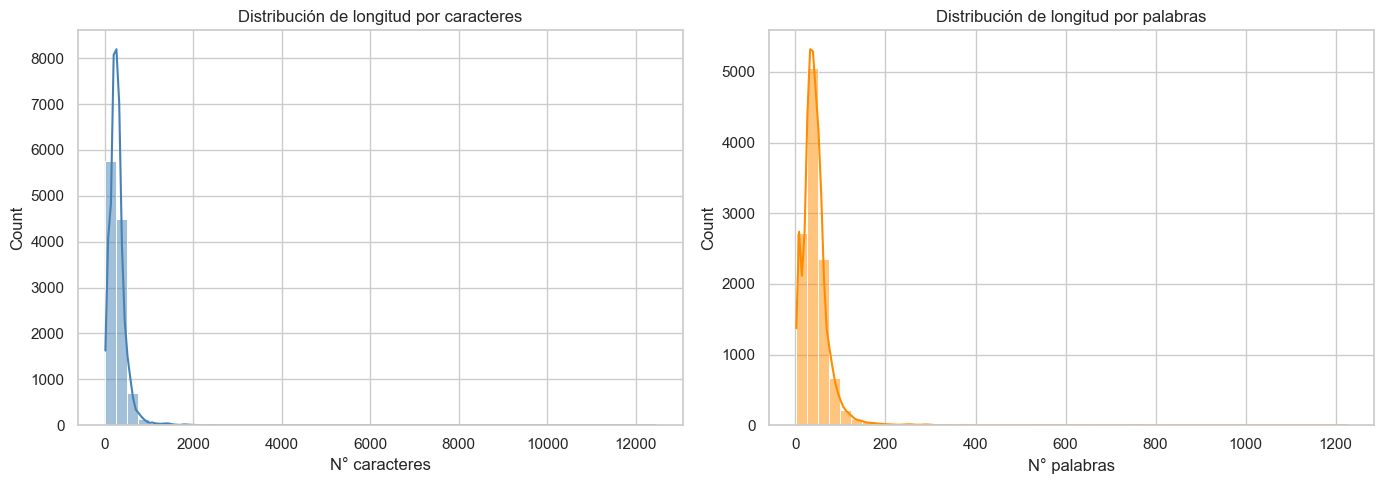

In [57]:
# 6) Longitud del texto: chars y palabras
df_len = df_eda.loc[~df_eda["texto_vacio"]].copy()
df_len["len_chars"] = df_len["texto_unificado_raw"].str.len()
df_len["len_words"] = df_len["texto_unificado_raw"].str.split().str.len()

print(df_len[["len_chars", "len_words"]].describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.95, 0.99]))

fig, ax = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(df_len["len_chars"], bins=50, kde=True, ax=ax[0], color="steelblue")
ax[0].set_title("Distribución de longitud por caracteres")
ax[0].set_xlabel("N° caracteres")

sns.histplot(df_len["len_words"], bins=50, kde=True, ax=ax[1], color="darkorange")
ax[1].set_title("Distribución de longitud por palabras")
ax[1].set_xlabel("N° palabras")

plt.tight_layout()
plt.show()

In [58]:
# 7) Señal de "plantillas" repetitivas en short_description
top_short = (
    df_eda["short_description"]
    .fillna("VACIO")
    .astype(str)
    .str.strip()
    .value_counts()
    .head(15)
)

print("Top 15 short_description más frecuentes:")
display(top_short.to_frame("frecuencia"))

Top 15 short_description más frecuentes:


,frecuencia
short_description,
Requerimientos de información relacionados a Bancs y BancsLink,10723
Atención solicitudes Bancs y BancsLinks,399
Procesos Batch,20
Requerimientos de Información Mantenimiento,13
Requerimientos para facturación estados de cuenta,11
SISREP - Requerimientos de información relacionados a Bancs y BancsLink,8
"Creación, modificación, eliminación de perfiles globales y gestión de accesos a nivel de perfil global o transaccional de aplicaciones",5
Requerimiento Iniciativas Cambios,5
Requerimientos Cash,3


# Limpieza inicial - Requerimientos (No supervisado)

Objetivo: limpieza de datos previa al modelado

In [59]:
# 8) Separar dataset de modelado (solo texto) y dataset de auditoría
# number se conserva SOLO para trazabilidad, no para features
df_model = df_eda[["number", "short_description", "description"]].copy()

print("Registros base:", len(df_model))
display(df_model.head(3))

Registros base: 11216


,number,short_description,description
0,RITM0716416,Requerimientos de información relacionados a B...,Estimados su gentil ayuda con el cambio de es...
1,RITM0620071,Requerimientos de información relacionados a B...,¿Cómo se genera la información del archivo de ...
2,RITM0754745,Requerimientos de información relacionados a B...,¿Buenos días por favor su ayuda con revisión a...


In [60]:
# 9) Limpieza textual robusta para clustering
import re
import unicodedata

def normalize_text(texto):
    if pd.isna(texto):
        return ""

    t = str(texto).strip().lower()

    # Normaliza unicode y elimina caracteres raros
    t = unicodedata.normalize("NFKD", t)
    t = t.encode("ascii", "ignore").decode("utf-8", errors="ignore")

    # Enmascarar patrones que meten ruido semantico
    t = re.sub(r"(https?://\S+|www\.\S+)", " url ", t)
    t = re.sub(r"\b[\w\.-]+@[\w\.-]+\.\w+\b", " email ", t)
    t = re.sub(r"\b\d{1,2}[/-]\d{1,2}[/-]\d{2,4}\b", " fecha ", t)
    t = re.sub(r"\b\d{7,}\b", " num_largo ", t)   # cuentas, RUC, teller, etc.
    t = re.sub(r"\b\d+\b", " num ", t)

    # Limpieza general
    t = re.sub(r"[_\-=/\\\|\(\)\[\]\{\},;:]+", " ", t)
    t = re.sub(r"[^a-z0-9\s]", " ", t)
    t = re.sub(r"\s+", " ", t).strip()

    return t

In [61]:
# 10) Limpiar columnas textuales
df_model["short_clean"] = df_model["short_description"].apply(normalize_text)
df_model["desc_clean"] = df_model["description"].apply(normalize_text)

# short_description suele ser plantilla; description lleva mas señal
# Damos mayor peso a description repitiendola una vez adicional
df_model["texto_limpio"] = (
    df_model["short_clean"] + " " +
    df_model["desc_clean"] + " " +
    df_model["desc_clean"]
).str.replace(r"\s+", " ", regex=True).str.strip()

display(df_model[["short_description", "description", "texto_limpio"]].head(3))

,short_description,description,texto_limpio
0,Requerimientos de información relacionados a B...,Estimados su gentil ayuda con el cambio de es...,requerimientos de informacion relacionados a b...
1,Requerimientos de información relacionados a B...,¿Cómo se genera la información del archivo de ...,requerimientos de informacion relacionados a b...
2,Requerimientos de información relacionados a B...,¿Buenos días por favor su ayuda con revisión a...,requerimientos de informacion relacionados a b...


In [62]:
# Validación de limpieza
muestra_validacion = df_model[[
    "number", "short_description", "description", "short_clean", "desc_clean", "texto_limpio"
]].head(10).copy()

display(muestra_validacion)

print("Conteo de placeholders en texto_limpio:")
print("fecha:", int(df_model["texto_limpio"].str.contains(r"\bfecha\b", regex=True).sum()))
print("num_largo:", int(df_model["texto_limpio"].str.contains(r"\bnum_largo\b", regex=True).sum()))
print("num:", int(df_model["texto_limpio"].str.contains(r"\bnum\b", regex=True).sum()))
print("email:", int(df_model["texto_limpio"].str.contains(r"\bemail\b", regex=True).sum()))
print("url:", int(df_model["texto_limpio"].str.contains(r"\burl\b", regex=True).sum()))

print("\nConteo de caracteres raros remanentes:")
print(" :", int(df_model["texto_limpio"].str.contains("", regex=False).sum()))
print("� :", int(df_model["texto_limpio"].str.contains("�", regex=False).sum()))
print("¿ :", int(df_model["texto_limpio"].str.contains("¿", regex=False).sum()))
print("¡ :", int(df_model["texto_limpio"].str.contains("¡", regex=False).sum()))

,number,short_description,description,short_clean,desc_clean,texto_limpio
0,RITM0716416,Requerimientos de información relacionados a B...,Estimados su gentil ayuda con el cambio de es...,requerimientos de informacion relacionados a b...,estimados su gentil ayuda con el cambio de est...,requerimientos de informacion relacionados a b...
1,RITM0620071,Requerimientos de información relacionados a B...,¿Cómo se genera la información del archivo de ...,requerimientos de informacion relacionados a b...,como se genera la informacion del archivo de c...,requerimientos de informacion relacionados a b...
2,RITM0754745,Requerimientos de información relacionados a B...,¿Buenos días por favor su ayuda con revisión a...,requerimientos de informacion relacionados a b...,buenos dias por favor su ayuda con revision a ...,requerimientos de informacion relacionados a b...
3,RITM0795775,Requerimientos de información relacionados a B...,]Estimado su gentil apoyo con el pedido del cl...,requerimientos de informacion relacionados a b...,estimado su gentil apoyo con el pedido del cli...,requerimientos de informacion relacionados a b...
4,RITM0424331,Requerimientos de información relacionados a B...,[Iniciativa Multi Core] - Configuración de Cup...,requerimientos de informacion relacionados a b...,iniciativa multi core configuracion de cupos s...,requerimientos de informacion relacionados a b...
5,RITM0709362,Requerimientos de información relacionados a B...,Versionar el shell camRepCanjeEnf1.sh.,requerimientos de informacion relacionados a b...,versionar el shell camrepcanjeenf1 sh,requerimientos de informacion relacionados a b...
6,RITM0658358,Requerimientos de información relacionados a B...,Versionar el proceso dev_check.sh y posterior ...,requerimientos de informacion relacionados a b...,versionar el proceso dev check sh y posterior ...,requerimientos de informacion relacionados a b...
7,RITM0594481,Requerimientos de información relacionados a B...,Versionar el proceso dev_check.sh y posterior ...,requerimientos de informacion relacionados a b...,versionar el proceso dev check sh y posterior ...,requerimientos de informacion relacionados a b...
8,RITM0625900,Requerimientos de información relacionados a B...,Versionar el proceso dev_check.sh y posterior ...,requerimientos de informacion relacionados a b...,versionar el proceso dev check sh y posterior ...,requerimientos de informacion relacionados a b...
9,RITM0741342,Requerimientos de información relacionados a B...,Ver movimientos de BANCS por petición de MONTE...,requerimientos de informacion relacionados a b...,ver movimientos de bancs por peticion de monte...,requerimientos de informacion relacionados a b...


Conteo de placeholders en texto_limpio:
fecha: 2063
num_largo: 0
num: 7750
email: 95
url: 90

Conteo de caracteres raros remanentes:
 : 0
� : 0
¿ : 0
¡ : 0


In [63]:
# 11) Filtrar textos no informativos
df_model["n_tokens"] = df_model["texto_limpio"].str.split().str.len()

# Regla base: al menos 4 tokens utiles
df_model["valido_modelo"] = df_model["n_tokens"] >= 4

print("Registros validos para modelo:", int(df_model["valido_modelo"].sum()))
print("Registros descartados por poco texto:", int((~df_model["valido_modelo"]).sum()))

display(df_model.loc[~df_model["valido_modelo"], ["number", "texto_limpio", "n_tokens"]].head(10))

Registros validos para modelo: 11203
Registros descartados por poco texto: 13


,number,texto_limpio,n_tokens
10003,RITM0804446,accesos cyberark,2
10022,RITM0110936,procesos batch,2
10080,RITM0112488,procesos batch,2
10137,RITM0300491,procesos batch,2
10446,RITM0390620,requerimiento iniciativas cambios,3
10467,RITM0327879,requerimiento iniciativas cambios,3
10621,RITM0266502,soporte redes,2
10660,RITM0111247,procesos batch,2
10714,RITM0059903,procesos batch,2
10942,RITM0197186,procesos batch,2


In [64]:
# 12) Crear dataset de entrenamiento para clustering
df_fit_full = df_model.loc[df_model["valido_modelo"], ["number", "texto_limpio"]].copy()

# Deduplicado exacto SOLO para ajustar modelo sin sesgo por repeticion
df_fit_unique = (
    df_fit_full
    .drop_duplicates(subset=["texto_limpio"])
    .reset_index(drop=True)
)

print("Registros para fit (con repetidos):", len(df_fit_full))
print("Registros para fit (texto unico):", len(df_fit_unique))
print("Reduccion:", round((1 - len(df_fit_unique) / len(df_fit_full)) * 100, 2), "%")

Registros para fit (con repetidos): 11203
Registros para fit (texto unico): 8393
Reduccion: 25.08 %


In [65]:
# 13) Frecuencia de textos (importante para analisis operativo)
freq_texto = (
    df_fit_full
    .groupby("texto_limpio", as_index=False)
    .agg(
        frecuencia=("number", "count"),
        ejemplos_number=("number", lambda x: ", ".join(x.head(5)))
    )
    .sort_values("frecuencia", ascending=False)
    .reset_index(drop=True)
)

display(freq_texto.head(15))

,texto_limpio,frecuencia,ejemplos_number
0,requerimientos de informacion relacionados a b...,1214,"RITM0549138, RITM0293805, RITM0454559, RITM036..."
1,requerimientos de informacion relacionados a b...,226,"RITM0527477, RITM0753925, RITM0516740, RITM086..."
2,atencion solicitudes bancs y bancslinks,94,"RITM0061258, RITM0058580, RITM0086319, RITM008..."
3,requerimientos de informacion relacionados a b...,68,"RITM0688742, RITM0686756, RITM0722457, RITM088..."
4,requerimientos de informacion relacionados a b...,46,"RITM0745463, RITM0737022, RITM0731743, RITM071..."
5,requerimientos de informacion relacionados a b...,45,"RITM0363677, RITM0831353, RITM0585399, RITM058..."
6,requerimientos de informacion relacionados a b...,26,"RITM0795321, RITM0754302, RITM0789271, RITM072..."
7,requerimientos de informacion relacionados a b...,17,"RITM0569512, RITM0571823, RITM0567938, RITM056..."
8,requerimientos de informacion relacionados a b...,15,"RITM0465337, RITM0465343, RITM0465361, RITM046..."
9,requerimientos de informacion relacionados a b...,14,"RITM0752372, RITM0696120, RITM0603099, RITM085..."


In [66]:
# 14) Objetos que usaremos en clustering
# - df_fit_unique["texto_limpio"] -> entrenamiento del clustering
# - df_fit_full -> para asignar cluster a todos los tickets validos
# - df_model -> para trazabilidad completa por number
print("Listo para clustering no supervisado.")
print("Variables clave: df_fit_unique, df_fit_full, df_model, freq_texto")

Listo para clustering no supervisado.
Variables clave: df_fit_unique, df_fit_full, df_model, freq_texto


In [67]:
# 15) Remover boilerplate de negocio (v5 robusto)

boilerplate_patterns = [
    # Encabezados tipicos de short_description
    r"\brequerimientos?\s+de\s+informacion\s+relacionados?\s+a\s+bancs?\s+y\s+bancslinks?\b",
    r"\batencion\s+solicitudes?\s+bancs?\s+y\s+bancslinks?\b",

    # Saludos y apertura
    r"^\s*estimad[oa]s?\b",
    r"^\s*buen[oa]s?\s+d[ii]as\b",
    r"^\s*buen[oa]s?\s+tardes\b",
    r"^\s*buen[oa]s?\s+noches\b",
    r"\bespero\s+se\s+encuentren\s+bien\b",

    # Frases blandas frecuentes
    r"\bpor\s+favor\b",
    r"\bfavor\b",
    r"\bfavor\s+con\b",
    r"\bsu\s+gentil\s+ayuda\b",
    r"\bsu\s+ayuda\b",
    r"\bsu\s+gentil\s+apoyo\b",
    r"\bsu\s+apoyo\b",
    r"\bgentil\s+apoyo\b",
    r"\bfavor\s+su\s+ayuda\b",
    r"\bpor\s+favor\s+su\s+ayuda\s+con\b",
    r"\bpor\s+favor\s+su\s+apoyo\s+con\b",
    r"\bpor\s+favor\s+apoyar\b",
    r"\bpor\s+favor\s+ayudar\b",
    r"\bsu\s+gentil\s+apoyo\s+con\b",
    r"\bsu\s+ayuda\s+con\b",
    r"\bapoyo\s+con\b",
    r"\bayuda\s+con\b",

    # Cierre y cortesia
    r"\batenta?\s+a\s+sus\s+comentarios\b",
    r"\bquedo\s+atent[oa]\b",
    r"\bde\s+antemano\b",
    r"\bles\s+agradezco\b",
    r"\bagradezco\s+su\s+ayuda\b",
    r"\bcordial(?:es)?\s+saludos\b",
    r"\bsaludos?\s+cordiales?\b",
    r"\bsaludos?\b",
    r"\bgracias\b",
    r"\badjunto\b",
]

boilerplate_regex = re.compile("|".join(boilerplate_patterns))
prefix_regex = re.compile(r"^(con|con el|con la|con los|con las|para|sobre|del|de la|de los|de las)\s+")

def strip_boilerplate(texto):
    if pd.isna(texto):
        return ""
    t = str(texto)

    # 1) quitar boilerplate en varias pasadas
    for _ in range(6):
        t_new = boilerplate_regex.sub(" ", t)
        t_new = re.sub(r"\s+", " ", t_new).strip()
        if t_new == t:
            break
        t = t_new

    # 2) quitar conectores residuales al inicio
    for _ in range(4):
        t_new = prefix_regex.sub("", t).strip()
        if t_new == t:
            break
        t = t_new

    # 3) limpieza final
    t = re.sub(r"\s+", " ", t).strip()
    return t

df_model["short_core"] = df_model["short_clean"].apply(strip_boilerplate)
df_model["desc_core"] = df_model["desc_clean"].apply(strip_boilerplate)

display(df_model[["short_clean", "short_core", "desc_clean", "desc_core"]].head(10))

,short_clean,short_core,desc_clean,desc_core
0,requerimientos de informacion relacionados a b...,,estimados su gentil ayuda con el cambio de est...,el cambio de estado chequera cta cte num largo...
1,requerimientos de informacion relacionados a b...,,como se genera la informacion del archivo de c...,como se genera la informacion del archivo de c...
2,requerimientos de informacion relacionados a b...,,buenos dias por favor su ayuda con revision a ...,revision a que corresponde estos valores clien...
3,requerimientos de informacion relacionados a b...,,estimado su gentil apoyo con el pedido del cli...,el pedido del cliente pinturas color num s a s...
4,requerimientos de informacion relacionados a b...,,iniciativa multi core configuracion de cupos s...,iniciativa multi core configuracion de cupos s...
5,requerimientos de informacion relacionados a b...,,versionar el shell camrepcanjeenf1 sh,versionar el shell camrepcanjeenf1 sh
6,requerimientos de informacion relacionados a b...,,versionar el proceso dev check sh y posterior ...,versionar el proceso dev check sh y posterior ...
7,requerimientos de informacion relacionados a b...,,versionar el proceso dev check sh y posterior ...,versionar el proceso dev check sh y posterior ...
8,requerimientos de informacion relacionados a b...,,versionar el proceso dev check sh y posterior ...,versionar el proceso dev check sh y posterior ...
9,requerimientos de informacion relacionados a b...,,ver movimientos de bancs por peticion de monte...,ver movimientos de bancs por peticion de monte...


In [68]:
# 16) Construir texto final priorizando description (v3)
def es_texto_informativo(txt, min_tokens=4):
    if pd.isna(txt):
        return False
    t = str(txt).strip()
    if t == "":
        return False
    return len(t.split()) >= min_tokens

def construir_texto_final(row):
    d = row["desc_core"] if pd.notna(row["desc_core"]) else ""
    s = row["short_core"] if pd.notna(row["short_core"]) else ""

    d_ok = es_texto_informativo(d, min_tokens=4)
    s_ok = es_texto_informativo(s, min_tokens=4)

    if d_ok and s_ok:
        return (d + " " + s).strip(), "desc_core+short_core"
    if d_ok:
        return d.strip(), "desc_core"
    if s_ok:
        return s.strip(), "short_core"

    # Si ninguno es informativo, no reinyectar short_clean genérico automáticamente
    return "", "none"

tmp = df_model.apply(construir_texto_final, axis=1)
df_model["texto_limpio_v2"] = tmp.apply(lambda x: x[0])
df_model["source_text_v2"] = tmp.apply(lambda x: x[1])

display(df_model[["description", "short_description", "desc_core", "short_core", "texto_limpio_v2", "source_text_v2"]].head(10))
print(df_model["source_text_v2"].value_counts(dropna=False))

,description,short_description,desc_core,short_core,texto_limpio_v2,source_text_v2
0,Estimados su gentil ayuda con el cambio de es...,Requerimientos de información relacionados a B...,el cambio de estado chequera cta cte num largo...,,el cambio de estado chequera cta cte num largo...,desc_core
1,¿Cómo se genera la información del archivo de ...,Requerimientos de información relacionados a B...,como se genera la informacion del archivo de c...,,como se genera la informacion del archivo de c...,desc_core
2,¿Buenos días por favor su ayuda con revisión a...,Requerimientos de información relacionados a B...,revision a que corresponde estos valores clien...,,revision a que corresponde estos valores clien...,desc_core
3,]Estimado su gentil apoyo con el pedido del cl...,Requerimientos de información relacionados a B...,el pedido del cliente pinturas color num s a s...,,el pedido del cliente pinturas color num s a s...,desc_core
4,[Iniciativa Multi Core] - Configuración de Cup...,Requerimientos de información relacionados a B...,iniciativa multi core configuracion de cupos s...,,iniciativa multi core configuracion de cupos s...,desc_core
5,Versionar el shell camRepCanjeEnf1.sh.,Requerimientos de información relacionados a B...,versionar el shell camrepcanjeenf1 sh,,versionar el shell camrepcanjeenf1 sh,desc_core
6,Versionar el proceso dev_check.sh y posterior ...,Requerimientos de información relacionados a B...,versionar el proceso dev check sh y posterior ...,,versionar el proceso dev check sh y posterior ...,desc_core
7,Versionar el proceso dev_check.sh y posterior ...,Requerimientos de información relacionados a B...,versionar el proceso dev check sh y posterior ...,,versionar el proceso dev check sh y posterior ...,desc_core
8,Versionar el proceso dev_check.sh y posterior ...,Requerimientos de información relacionados a B...,versionar el proceso dev check sh y posterior ...,,versionar el proceso dev check sh y posterior ...,desc_core
9,Ver movimientos de BANCS por petición de MONTE...,Requerimientos de información relacionados a B...,ver movimientos de bancs por peticion de monte...,,ver movimientos de bancs por peticion de monte...,desc_core


source_text_v2
desc_core               9826
none                    1345
desc_core+short_core      43
short_core                 2
Name: count, dtype: int64


In [69]:
# 17) Recalcular filtro de textos informativos con v2
df_model["n_tokens_v2"] = df_model["texto_limpio_v2"].str.split().str.len().fillna(0).astype(int)
df_model["valido_modelo_v2"] = df_model["n_tokens_v2"] >= 4

print("Validos v2:", int(df_model["valido_modelo_v2"].sum()))
print("Descartados v2:", int((~df_model["valido_modelo_v2"]).sum()))

print("\nDescarte por fuente:")
display(df_model.loc[~df_model["valido_modelo_v2"], "source_text_v2"].value_counts(dropna=False).to_frame("conteo"))

display(df_model.loc[~df_model["valido_modelo_v2"], ["number", "source_text_v2", "texto_limpio_v2", "n_tokens_v2"]].head(10))

Validos v2: 9871
Descartados v2: 1345

Descarte por fuente:


,conteo
source_text_v2,
none,1345


,number,source_text_v2,texto_limpio_v2,n_tokens_v2
160,RITM0073151,none,,0
191,RITM0542626,none,,0
1989,RITM0394170,none,,0
2052,RITM0618044,none,,0
2728,RITM0905678,none,,0
2729,RITM0679373,none,,0
3652,RITM0730451,none,,0
3691,RITM0821120,none,,0
5644,RITM0860995,none,,0
5656,RITM0876265,none,,0


In [70]:
# 18) Recalcular fit y deduplicación con v2
df_fit_full_v2 = df_model.loc[df_model["valido_modelo_v2"], ["number", "texto_limpio_v2", "source_text_v2"]].copy()

df_fit_unique_v2 = (
    df_fit_full_v2
    .drop_duplicates(subset=["texto_limpio_v2"])
    .reset_index(drop=True)
)

print("Fit v2 (con repetidos):", len(df_fit_full_v2))
print("Fit v2 (texto unico):", len(df_fit_unique_v2))
print("Reduccion v2:", round((1 - len(df_fit_unique_v2) / len(df_fit_full_v2)) * 100, 2), "%")

Fit v2 (con repetidos): 9871
Fit v2 (texto unico): 8321
Reduccion v2: 15.7 %


In [71]:
# 19) Frecuencias top con v2
freq_texto_v2 = (
    df_fit_full_v2
    .groupby("texto_limpio_v2", as_index=False)
    .agg(
        frecuencia=("number", "count"),
        ejemplos_number=("number", lambda x: ", ".join(x.head(5))),
        fuente_predominante=("source_text_v2", lambda x: x.value_counts().index[0] if len(x) else "NA")
    )
    .sort_values("frecuencia", ascending=False)
    .reset_index(drop=True)
)

display(freq_texto_v2.head(15))

,texto_limpio_v2,frecuencia,ejemplos_number,fuente_predominante
0,el cambio de estado de pagado a activo del che...,229,"RITM0499870, RITM0362294, RITM0527477, RITM075...",desc_core
1,motor de transferencias con la informacion de ...,68,"RITM0688742, RITM0686756, RITM0722457, RITM088...",desc_core
2,la obtencion de la glif del archivo,50,"RITM0363677, RITM0831353, RITM0585399, RITM058...",desc_core
3,solicito su amable colaboracion con la validac...,46,"RITM0745463, RITM0737022, RITM0731743, RITM071...",desc_core
4,el cambio de estado a deteriorado las formas n...,26,"RITM0795321, RITM0754302, RITM0789271, RITM072...",desc_core
5,motor de transferencias con los siguientes dat...,17,"RITM0569512, RITM0571823, RITM0567938, RITM056...",desc_core
6,la glif del archivo y enviarmelo,16,"RITM0400978, RITM0411181, RITM0407774, RITM073...",desc_core
7,se requiere el cambio de estado a resuelto r e...,15,"RITM0465337, RITM0465343, RITM0465361, RITM046...",desc_core
8,la generacion del reporte de opciones de bancs...,14,"RITM0130191, RITM0288307, RITM0207608, RITM014...",desc_core
9,la generacion de un reporte con corte al num n...,14,"RITM0752372, RITM0696120, RITM0603099, RITM085...",desc_core


In [72]:
# 20) Comparativa v1 vs v2 en dominancia top1
top1_v1 = freq_texto.iloc[0]["frecuencia"] if len(freq_texto) else 0
top1_v2 = freq_texto_v2.iloc[0]["frecuencia"] if len(freq_texto_v2) else 0

print("Top1 frecuencia v1:", top1_v1)
print("Top1 frecuencia v2:", top1_v2)
if top1_v1 > 0:
    print("Cambio porcentual top1:", round((top1_v2 - top1_v1) / top1_v1 * 100, 2), "%")

Top1 frecuencia v1: 1214
Top1 frecuencia v2: 229
Cambio porcentual top1: -81.14 %


# Entrenamiento inicial - Requerimientos (No supervisado)

Objetivo: explorar calidad y estructura de datos para preparar un modelo no supervisado usando únicamente short_description y description.
Variables de fuga como assignment_group y assigned_to no se usarán para modelado.

In [73]:
#Celda 21 - Imports para split y modelado
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import Normalizer
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
import numpy as np
import pandas as pd

RANDOM_STATE = 42

In [74]:
# 22) Base para split train/val/test (solo textos válidos y únicos)
df_unique = df_fit_unique_v2.copy().reset_index(drop=True)
df_unique = df_unique[df_unique["texto_limpio_v2"].fillna("").str.strip().ne("")].copy()

print("Total textos únicos válidos:", len(df_unique))

# Split 70/15/15
train_df, temp_df = train_test_split(
    df_unique,
    test_size=0.30,
    random_state=RANDOM_STATE
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    random_state=RANDOM_STATE
)

print("Train:", len(train_df))
print("Validación:", len(val_df))
print("Test:", len(test_df))
print("Check total:", len(train_df) + len(val_df) + len(test_df))

Total textos únicos válidos: 8321
Train: 5824
Validación: 1248
Test: 1249
Check total: 8321


In [75]:
# 23) Vectorizacion + reduccion (fit SOLO con train)

STOP_ES = [
    "de","la","el","los","las","en","y","a","que","se","con","por","para","del","al",
    "su","sus","un","una","como","favor","apoyo","ayuda","gracias","estimado","estimada",
    "hola","buenos","buenas","dia","dias","tarde","tardes","noche","noches"
]

vectorizer = TfidfVectorizer(
    analyzer="word",
    ngram_range=(1, 2),
    min_df=3,
    max_features=120000,
    sublinear_tf=True,
    strip_accents="unicode",
    stop_words=STOP_ES
)

svd = TruncatedSVD(n_components=100, random_state=RANDOM_STATE)
norm = Normalizer(copy=False)

X_train_tfidf = vectorizer.fit_transform(train_df["texto_limpio_v2"])
X_val_tfidf = vectorizer.transform(val_df["texto_limpio_v2"])
X_test_tfidf = vectorizer.transform(test_df["texto_limpio_v2"])

X_train = norm.fit_transform(svd.fit_transform(X_train_tfidf))
X_val = norm.transform(svd.transform(X_val_tfidf))
X_test = norm.transform(svd.transform(X_test_tfidf))

print("Shapes:")
print("Train:", X_train.shape)
print("Val:", X_val.shape)
print("Test:", X_test.shape)

Shapes:
Train: (5824, 100)
Val: (1248, 100)
Test: (1249, 100)


In [76]:
# 24) Búsqueda de k con métricas de VALIDACIÓN
k_grid = list(range(8, 31, 2))
rows = []

for k in k_grid:
    km = KMeans(
        n_clusters=k,
        random_state=RANDOM_STATE,
        n_init=20
    )
    km.fit(X_train)

    val_labels = km.predict(X_val)
    n_val_clusters = len(np.unique(val_labels))

    if n_val_clusters > 1:
        sil_val = silhouette_score(X_val, val_labels, metric="euclidean")
        db_val = davies_bouldin_score(X_val, val_labels)            # menor es mejor
        ch_val = calinski_harabasz_score(X_val, val_labels)         # mayor es mejor
    else:
        sil_val = np.nan
        db_val = np.nan
        ch_val = np.nan

    rows.append({
        "k": k,
        "silhouette_val": sil_val,
        "davies_bouldin_val": db_val,
        "calinski_harabasz_val": ch_val,
        "inertia_train": km.inertia_,
        "clusters_en_val": int(n_val_clusters)
    })

df_k_eval = pd.DataFrame(rows).sort_values("silhouette_val", ascending=False).reset_index(drop=True)
display(df_k_eval)

best_k = int(df_k_eval.loc[0, "k"])
best_row = df_k_eval.loc[0]

print("=== MÉTRICAS DE VALIDACIÓN (mejor k) ===")
print("k:", best_k)
print("silhouette_val:", round(float(best_row["silhouette_val"]), 6))
print("davies_bouldin_val:", round(float(best_row["davies_bouldin_val"]), 6))
print("calinski_harabasz_val:", round(float(best_row["calinski_harabasz_val"]), 6))
print("clusters_en_val:", int(best_row["clusters_en_val"]))

,k,silhouette_val,davies_bouldin_val,calinski_harabasz_val,inertia_train,clusters_en_val
0,30,0.131943,2.465196,24.454795,3471.972983,30
1,26,0.126286,2.518961,25.557278,3574.470951,26
2,24,0.120349,2.661953,26.529127,3649.620744,24
3,28,0.118365,2.469904,25.087607,3508.288391,28
4,22,0.115378,2.707476,27.261983,3712.941857,22
5,20,0.110289,2.760114,28.083561,3783.620859,20
6,18,0.103952,2.818200,29.148083,3860.051695,18
7,16,0.102048,2.912081,30.787990,3941.159705,16
8,14,0.096441,3.101812,31.502246,4035.734367,14
9,12,0.094327,3.115928,34.114681,4122.519070,12


=== MÉTRICAS DE VALIDACIÓN (mejor k) ===
k: 30
silhouette_val: 0.131943
davies_bouldin_val: 2.465196
calinski_harabasz_val: 24.454795
clusters_en_val: 30


In [77]:
# 25) Reentrenar con train+val y evaluar en TEST (metricas impresas)

trainval_df = pd.concat([train_df, val_df], axis=0).reset_index(drop=True)

vectorizer_tv = TfidfVectorizer(
    analyzer="word",
    ngram_range=(1, 2),
    min_df=3,
    max_features=120000,
    sublinear_tf=True,
    strip_accents="unicode",
    stop_words=STOP_ES
)

svd_tv = TruncatedSVD(n_components=100, random_state=RANDOM_STATE)
norm_tv = Normalizer(copy=False)

X_trainval_tfidf = vectorizer_tv.fit_transform(trainval_df["texto_limpio_v2"])
X_test_tfidf_tv = vectorizer_tv.transform(test_df["texto_limpio_v2"])

X_trainval = norm_tv.fit_transform(svd_tv.fit_transform(X_trainval_tfidf))
X_test_tv = norm_tv.transform(svd_tv.transform(X_test_tfidf_tv))

kmeans_tv = KMeans(
    n_clusters=best_k,
    random_state=RANDOM_STATE,
    n_init=20
)
kmeans_tv.fit(X_trainval)

test_labels = kmeans_tv.predict(X_test_tv)
n_test_clusters = len(np.unique(test_labels))

if n_test_clusters > 1:
    sil_test = silhouette_score(X_test_tv, test_labels, metric="euclidean")
    db_test = davies_bouldin_score(X_test_tv, test_labels)
    ch_test = calinski_harabasz_score(X_test_tv, test_labels)
else:
    sil_test = np.nan
    db_test = np.nan
    ch_test = np.nan

val_best = df_k_eval.loc[df_k_eval["k"] == best_k].iloc[0]

print("=== METRICAS VALIDACION vs TEST ===")
print("k elegido:", best_k)

print("\nValidacion:")
print("silhouette_val:", round(float(val_best["silhouette_val"]), 6))
print("davies_bouldin_val:", round(float(val_best["davies_bouldin_val"]), 6))
print("calinski_harabasz_val:", round(float(val_best["calinski_harabasz_val"]), 6))

print("\nTest:")
print("silhouette_test:", round(float(sil_test), 6) if pd.notna(sil_test) else np.nan)
print("davies_bouldin_test:", round(float(db_test), 6) if pd.notna(db_test) else np.nan)
print("calinski_harabasz_test:", round(float(ch_test), 6) if pd.notna(ch_test) else np.nan)
print("clusters_en_test:", int(n_test_clusters))

=== METRICAS VALIDACION vs TEST ===
k elegido: 30

Validacion:
silhouette_val: 0.131943
davies_bouldin_val: 2.465196
calinski_harabasz_val: 24.454795

Test:
silhouette_test: 0.122005
davies_bouldin_test: 2.370768
calinski_harabasz_test: 24.08135
clusters_en_test: 30


In [78]:
# 26) Modelo final operativo (fit con TODOS los textos unicos validos)

vectorizer_final = TfidfVectorizer(
    analyzer="word",
    ngram_range=(1, 2),
    min_df=3,
    max_features=120000,
    sublinear_tf=True,
    strip_accents="unicode",
    stop_words=STOP_ES
)

svd_final = TruncatedSVD(n_components=100, random_state=RANDOM_STATE)
norm_final = Normalizer(copy=False)

X_unique_tfidf = vectorizer_final.fit_transform(df_fit_unique_v2["texto_limpio_v2"])
X_unique = norm_final.fit_transform(svd_final.fit_transform(X_unique_tfidf))

kmeans_final = KMeans(
    n_clusters=best_k,
    random_state=RANDOM_STATE,
    n_init=20
)
kmeans_final.fit(X_unique)

print("Modelo final ajustado con k =", best_k)

Modelo final ajustado con k = 30


In [79]:
# 27) Asignación de clusters a válidos y manejo explícito de NONE (robusto)

# 27.1 Asignar cluster a todos los válidos (con repetidos)
X_full_tfidf = vectorizer_final.transform(df_fit_full_v2["texto_limpio_v2"])
X_full = norm_final.transform(svd_final.transform(X_full_tfidf))
df_fit_full_v2 = df_fit_full_v2.copy()
df_fit_full_v2["cluster_id"] = kmeans_final.predict(X_full).astype(int)

# 27.2 Llevar resultados al universo completo
df_result = df_model.copy()

tmp_assign = (
    df_fit_full_v2[["number", "cluster_id"]]
    .drop_duplicates(subset=["number"])
    .rename(columns={"cluster_id": "cluster_id_pred"})
)

df_result = df_result.merge(tmp_assign, on="number", how="left")

# Conversión robusta
df_result["cluster_id_pred"] = pd.to_numeric(df_result["cluster_id_pred"], errors="coerce")

# No clasificados = -1
df_result["cluster_id"] = df_result["cluster_id_pred"].fillna(-1).astype(int)
df_result = df_result.drop(columns=["cluster_id_pred"])

# Etiqueta final
df_result["estado_cluster"] = np.where(
    df_result["cluster_id"] == -1,
    "none_no_clasificable",
    "cluster_asignado"
)

print(df_result["estado_cluster"].value_counts(dropna=False))
display(df_result[["number", "texto_limpio_v2", "source_text_v2", "cluster_id", "estado_cluster"]].head(15))

estado_cluster
cluster_asignado        9871
none_no_clasificable    1345
Name: count, dtype: int64


,number,texto_limpio_v2,source_text_v2,cluster_id,estado_cluster
0,RITM0716416,el cambio de estado chequera cta cte num largo...,desc_core,29,cluster_asignado
1,RITM0620071,como se genera la informacion del archivo de c...,desc_core,17,cluster_asignado
2,RITM0754745,revision a que corresponde estos valores clien...,desc_core,24,cluster_asignado
3,RITM0795775,el pedido del cliente pinturas color num s a s...,desc_core,24,cluster_asignado
4,RITM0424331,iniciativa multi core configuracion de cupos s...,desc_core,20,cluster_asignado
5,RITM0709362,versionar el shell camrepcanjeenf1 sh,desc_core,26,cluster_asignado
6,RITM0658358,versionar el proceso dev check sh y posterior ...,desc_core,26,cluster_asignado
7,RITM0594481,versionar el proceso dev check sh y posterior ...,desc_core,26,cluster_asignado
8,RITM0625900,versionar el proceso dev check sh y posterior ...,desc_core,26,cluster_asignado
9,RITM0741342,ver movimientos de bancs por peticion de monte...,desc_core,18,cluster_asignado


In [80]:
# 28) Resumen de cobertura y tamaño de clusters

# Si no existe cluster_id en df_fit_full_v2, lo calculamos
if "cluster_id" not in df_fit_full_v2.columns:
    X_full_tfidf = vectorizer_final.transform(df_fit_full_v2["texto_limpio_v2"])
    X_full = norm_final.transform(svd_final.transform(X_full_tfidf))
    df_fit_full_v2 = df_fit_full_v2.copy()
    df_fit_full_v2["cluster_id"] = kmeans_final.predict(X_full).astype(int)

print("Total tickets:", len(df_model))
print("Asignados a cluster:", int((df_result["cluster_id"] != -1).sum()))
print("No clasificables (none):", int((df_result["cluster_id"] == -1).sum()))
print("Porcentaje none:", round((df_result["cluster_id"] == -1).mean() * 100, 2), "%")

cluster_sizes = (
    df_fit_full_v2["cluster_id"]
    .value_counts()
    .sort_index()
    .rename_axis("cluster_id")
    .reset_index(name="cantidad")
)

cluster_sizes["pct_sobre_asignados"] = (cluster_sizes["cantidad"] / cluster_sizes["cantidad"].sum() * 100).round(2)
display(cluster_sizes)

Total tickets: 11216
Asignados a cluster: 9871
No clasificables (none): 1345
Porcentaje none: 11.99 %


,cluster_id,cantidad,pct_sobre_asignados
0,0,230,2.33
1,1,246,2.49
2,2,332,3.36
3,3,286,2.90
4,4,488,4.94
5,5,522,5.29
6,6,212,2.15
7,7,139,1.41
8,8,234,2.37
9,9,444,4.50


In [82]:
# 29) Top términos y ejemplos por cluster (sin truncamiento)

import numpy as np
import pandas as pd

# Matriz tfidf del set asignado (válidos)
X_full_tfidf = vectorizer_final.transform(df_fit_full_v2["texto_limpio_v2"])
terms = np.array(vectorizer_final.get_feature_names_out())

top_n_terms = 12
top_n_examples = 5

rows = []
cluster_ids = sorted(df_fit_full_v2["cluster_id"].unique())

for cid in cluster_ids:
    idx = np.where(df_fit_full_v2["cluster_id"].values == cid)[0]
    if len(idx) == 0:
        continue

    mean_tfidf = X_full_tfidf[idx].mean(axis=0).A1
    top_idx = mean_tfidf.argsort()[-top_n_terms:][::-1]

    # Lista y string completo de top terms
    top_terms_list = terms[top_idx].tolist()
    top_terms_full = " | ".join(top_terms_list)

    rows.append({
        "cluster_id": int(cid),
        "cantidad": int(len(idx)),
        "top_terms_full": top_terms_full
    })

df_cluster_profile = (
    pd.DataFrame(rows)
    .sort_values("cantidad", ascending=False)
    .reset_index(drop=True)
)

# Mostrar sin truncamiento en notebook y también en print
with pd.option_context(
    "display.max_colwidth", None,
    "display.width", None,
    "display.max_columns", None,
    "display.max_rows", None
):
    display(df_cluster_profile)
    print("\n=== TOP TERMS COMPLETOS ===")
    print(df_cluster_profile.to_string(index=False))

print("\n=== EJEMPLOS POR CLUSTER (TEXTO COMPLETO) ===")
for cid in df_cluster_profile["cluster_id"].head(10):
    print(f"\nCluster {int(cid)}")
    muestra = (
        df_fit_full_v2.loc[df_fit_full_v2["cluster_id"] == cid, ["number", "texto_limpio_v2"]]
        .head(top_n_examples)
        .reset_index(drop=True)
    )

    # Impresión completa registro por registro
    for _, row in muestra.iterrows():
        print(f"- {row['number']}: {row['texto_limpio_v2']}")

,cluster_id,cantidad,top_terms_full
0,17,734,informacion | base | num | datos encuentran | encuentran excel | base journal | siguientes datos | fecha | journal fecha | excel | reporte | siguientes
1,15,605,num largo | largo | num | cuenta | cliente | no | ci num | ci | cuenta num | solicita | corriente | cuenta corriente
2,5,522,no | esta | si | lo | es | nos | cobrados | este | valores | num | informacion | estan
3,4,488,estado | destruido | destruccion | acta | fn | acta destruccion | cambio estado | cambio | estado fn | error | fn num | certificado
4,19,447,glif | archivo | glif archivo | obtencion glif | obtencion | num num | fecha | journals | num | acuerdo | test | journal
5,9,444,pagado | activo | mismo | estado pagado | estado activo | cheque | cheque num | pagado activo | fue pagado | pagado pero | estado | devolucion mismo
6,20,442,num | bancs | num num | transacciones | soporte | soporte bancs | transaccion | pruebas | siguientes | requiere | obtener | glifs
7,22,411,fecha | num | num num | fecha num | num largo | largo | fecha fecha | largo fecha | num fecha | largo num | cuenta | valor
8,18,389,movimientos | num num | soporte banca | banca empresas | empresas movimientos | banca | empresas | rango fechas | movimientos cliente | fechas | cliente rango | empresa
9,29,384,chequera | rango | num | rango num | num num | largo | num largo | estado chequera | mal | chequera cuenta | largo rango | cuenta



=== TOP TERMS COMPLETOS ===
 cluster_id  cantidad                                                                                                                                                                            top_terms_full
         17       734                                   informacion | base | num | datos encuentran | encuentran excel | base journal | siguientes datos | fecha | journal fecha | excel | reporte | siguientes
         15       605                                                                      num largo | largo | num | cuenta | cliente | no | ci num | ci | cuenta num | solicita | corriente | cuenta corriente
          5       522                                                                                                    no | esta | si | lo | es | nos | cobrados | este | valores | num | informacion | estan
          4       488                                                       estado | destruido | destruccion | acta | fn | acta destruccion